Task 2.1 Initial model development 
Develop a baseline ANN to predict Soil Organic Carbon (soil_organic_carbon_target) 
using a single hidden layer with 32 neurons with ReLU activation function.  
Compile the model using: 
• Loss Function: Mean Squared Error (MSE)  
• Optimizer: Adam (default learning rate)  
• Evaluation Metric: Mean Absolute Error (MAE)  
Train the model using: 
• Epochs: 100  
• Batch size: 32  
• Validation set: created in Part 1  
Set a random seed prior to training to ensure your results are reproducible. 

In [16]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import Perceptron

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    multilabel_confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error, 
    root_mean_squared_error, 
    r2_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.feature_selection import f_classif

import tensorflow as tf
import tensorflow.keras.backend as K


Read the dataset

In [17]:
# Read the dataset
df = pd.read_csv("../data/NZ_LUCAS_SMAP_NIWA.csv")

Even task 1's work shows that some of the attributes might have more correlation on the target attributes than others, I still run the model with all the attribues because when I tried to run the model with only the correlated attributed, the model does not produce very good R2-Score so I choose to run all the attributes 

separates input features (X) and target labels (y) and then, it splits dataset into three datasets: training dataset, test dataset and validation dataset 60%:20%:20% with the ratio 60% : 20% : 20%.  The datasets are scaled to prepare for the analysis. I also have a fix seed to make sure the results are can be produced the same. 

In [18]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

LabelEncoder

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD, Adagrad, RMSprop, Adadelta
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.models import Sequential

from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier

from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import numpy as np

import time
import keras_tuner as kt


In [19]:
import random

# Fix seeds for reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# Separate input features (X) and target labels (y)
X = df.drop(columns=['soil_organic_carbon_target', '36']).values # Input features
y = df['soil_organic_carbon_target'].values.reshape(-1, 1) # Target labels

# Splitting the dataset into three datasets for training, testing and validation with the ratio 60% : 20% : 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=seed)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=seed)

# Scaling data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)
X_val_scaled  = scaler_X.transform(X_val)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

Below is the baseline model: 

In [20]:
### Gradient Descent
# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with five neurons using ReLU activation function, and output layer which uses linear activation function to calculate output
gd_model = Sequential([
    Input(shape=(35,)),
    Dense(32, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), # Hidden layer with 5 neurons
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = SGD(learning_rate=0.001, momentum=0.0)

gd_model.compile(
    optimizer=opt,
    loss="mse",
    metrics=["mae"]
)


start_time = time.time()

# Train the model using GD with train dataset and validate the model using validation dataset during training
history_gd = gd_model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
gd_training_time = end_time - start_time

print(f"Training time: {gd_training_time:.2f} seconds")
print(f"Training time: {gd_training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9645 - mae: 0.7825 - val_loss: 0.9185 - val_mae: 0.7629
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9420 - mae: 0.7733 - val_loss: 0.8973 - val_mae: 0.7542
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9176 - mae: 0.7632 - val_loss: 0.8740 - val_mae: 0.7446
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8905 - mae: 0.7518 - val_loss: 0.8478 - val_mae: 0.7339
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8598 - mae: 0.7386 - val_loss: 0.8181 - val_mae: 0.7216
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8249 - mae: 0.7233 - val_loss: 0.7845 - val_mae: 0.7074
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7857 - mae: 0.7056 - val_loss: 0.7468 - val_mae: 0.6910
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7420 - mae: 0.6855 - val_loss: 0.7051 - val_mae: 0.6726
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.694

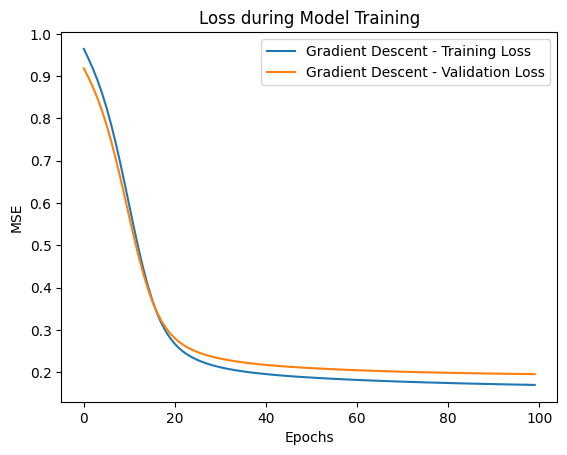

In [21]:
# Plot the training and validation accuracy and loss
plt.plot(history_gd.history["loss"], label="Gradient Descent - Training Loss")
plt.plot(history_gd.history["val_loss"], label="Gradient Descent - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

In the next step, I will try to tune the model with different layers from 1 to 4

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9970 - mae: 0.7939 - val_loss: 0.7134 - val_mae: 0.6716
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6000 - mae: 0.6149 - val_loss: 0.4816 - val_mae: 0.5578
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4152 - mae: 0.5118 - val_loss: 0.3686 - val_mae: 0.4901
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3231 - mae: 0.4517 - val_loss: 0.3092 - val_mae: 0.4470
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2739 - mae: 0.4157 - val_loss: 0.2757 - val_mae: 0.4211
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2456 - mae: 0.3935 - val_loss: 0.2553 - val_mae: 0.4040
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2282 - mae: 0.3791 - val_loss: 0.2421 - val_mae: 0.3922
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2169 - mae: 0.3693 - val_loss: 0.2331 - val_mae: 0.3846
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.209

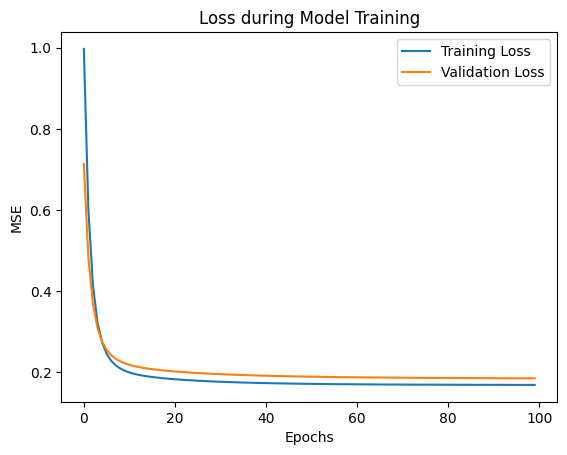

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9645 - mae: 0.7825 - val_loss: 0.9185 - val_mae: 0.7629
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9420 - mae: 0.7733 - val_loss: 0.8973 - val_mae: 0.7542
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9176 - mae: 0.7632 - val_loss: 0.8740 - val_mae: 0.7446
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8905 - mae: 0.7518 - val_loss: 0.8478 - val_mae: 0.7339
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8598 - mae: 0.7386 - val_loss: 0.8181 - val_mae: 0.7216
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8249 - mae: 0.7233 - val_loss: 0.7845 - val_mae: 0.7074
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7857 - mae: 0.7056 - val_loss: 0.7468 - val_mae: 0.6910
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7420 - mae: 0.6855 - val_loss: 0.7051 - val_mae: 0.6726
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.694

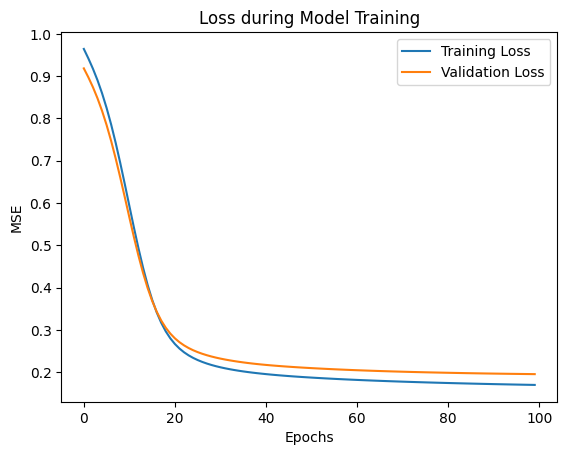

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0002 - mae: 0.7961 - val_loss: 0.9590 - val_mae: 0.7794
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9978 - mae: 0.7952 - val_loss: 0.9567 - val_mae: 0.7779
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9957 - mae: 0.7944 - val_loss: 0.9547 - val_mae: 0.7767
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9939 - mae: 0.7936 - val_loss: 0.9529 - val_mae: 0.7757
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9921 - mae: 0.7929 - val_loss: 0.9511 - val_mae: 0.7748
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9903 - mae: 0.7922 - val_loss: 0.9494 - val_mae: 0.7740
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9885 - mae: 0.7915 - val_loss: 0.9477 - val_mae: 0.7731
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9865 - mae: 0.7907 - val_loss: 0.9458 - val_mae: 0.7723
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.984

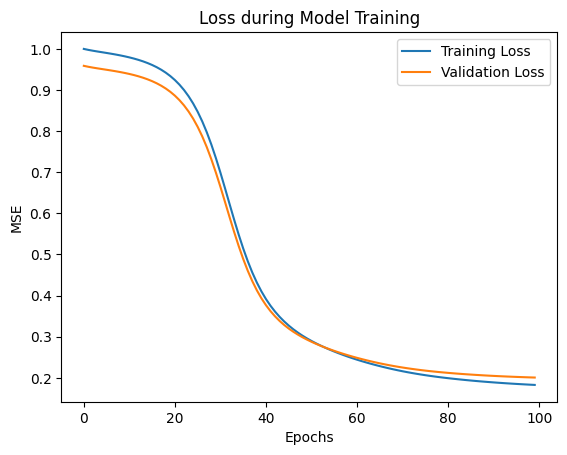

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0019 - mae: 0.7966 - val_loss: 0.9596 - val_mae: 0.7789
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0013 - mae: 0.7964 - val_loss: 0.9589 - val_mae: 0.7783
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0008 - mae: 0.7962 - val_loss: 0.9584 - val_mae: 0.7778
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0005 - mae: 0.7961 - val_loss: 0.9580 - val_mae: 0.7775
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0003 - mae: 0.7960 - val_loss: 0.9577 - val_mae: 0.7772
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0002 - mae: 0.7960 - val_loss: 0.9574 - val_mae: 0.7770
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0000 - mae: 0.7959 - val_loss: 0.9572 - val_mae: 0.7768
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9999 - mae: 0.7959 - val_loss: 0.9571 - val_mae: 0.7766
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.999

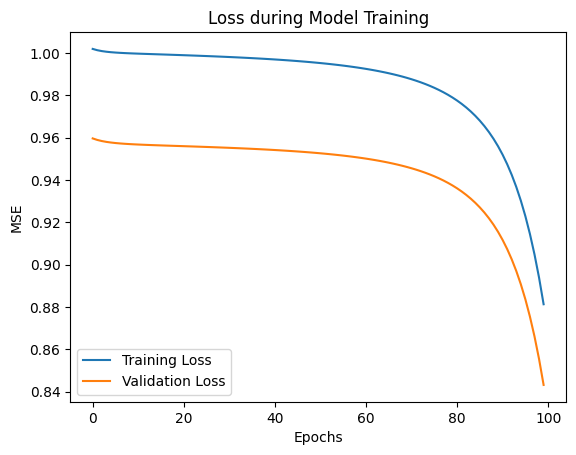

In [22]:
histories = {}
n_layers = [1,2,3,4]




for no_of_layers in n_layers:
# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
    
    model = Sequential([
    Input(shape=(35,))])

    for i in range(1,no_of_layers):
        model.add(Dense(32, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))) # Hidden layer with 5 neurons

    model.add(Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)))
    

    
    opt = SGD(learning_rate=0.001, momentum=0.0)

    model.compile(
        optimizer=opt,
        loss='mse',
        metrics=['mae']
)

    # Train the model using GD with train dataset and validate the model using validation dataset during training
    start_time = time.time()

    history_model = model.fit(
        X_train_scaled,
        y_train_scaled,
        epochs=100,
        batch_size=32, # batch_size > training_dataset_size --> use GD
        validation_data=(X_val_scaled, y_val_scaled),
        verbose=1
    )

    end_time = time.time()
    training_time = end_time - start_time

 


    
    histories[no_of_layers] = history_model

    # make Predictions using the Model
    y_true = y_test
    y_pred = np.argmax(model.predict(X_test_scaled), axis=1) # convert probabilities to class labels

    y_prob = model.predict(X_test_scaled)
    
    print('-----------------------------------------------------------------------------------------------------------------------')
    print('The results with %f no. of layers', no_of_layers)
    print('-----------------------------------------------------------------------------------------------------------------------')

   
   
   # Plot the training and validation accuracy and loss
    plt.plot(history_model.history["loss"], label="Training Loss")
    plt.plot(history_model.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.title("Loss during Model Training")
    plt.legend()
    plt.show()

  










From the analysis above, when the layers increase from 1 to 4, both msa and mae increased, so I will keep at one hidden layer. In the next step I will investigate the effect of varying the number of neurons per hidden layers. I will try with 16, 32, 64 and 128 neurons. 

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0037 - mae: 0.7980 - val_loss: 0.9596 - val_mae: 0.7787
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9947 - mae: 0.7944 - val_loss: 0.9515 - val_mae: 0.7752
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9858 - mae: 0.7909 - val_loss: 0.9432 - val_mae: 0.7717
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9764 - mae: 0.7871 - val_loss: 0.9343 - val_mae: 0.7681
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9659 - mae: 0.7829 - val_loss: 0.9243 - val_mae: 0.7641
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9538 - mae: 0.7781 - val_loss: 0.9127 - val_mae: 0.7594
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9397 - mae: 0.7723 - val_loss: 0.8989 - val_mae: 0.7539
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9229 - mae: 0.7654 - val_loss: 0.8826 - val_mae: 0.7474
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.903

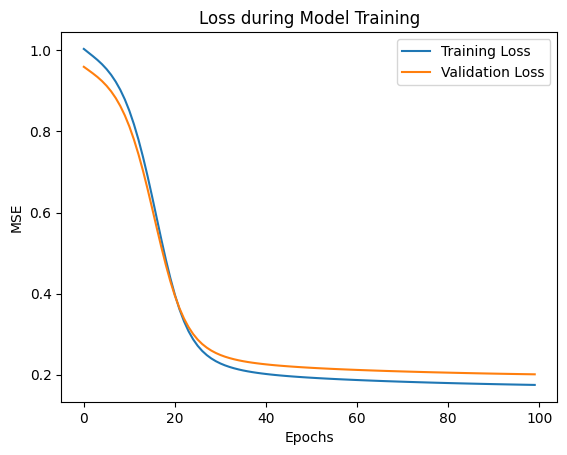

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9645 - mae: 0.7825 - val_loss: 0.9185 - val_mae: 0.7629
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9420 - mae: 0.7733 - val_loss: 0.8973 - val_mae: 0.7542
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9176 - mae: 0.7632 - val_loss: 0.8740 - val_mae: 0.7446
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8905 - mae: 0.7518 - val_loss: 0.8478 - val_mae: 0.7339
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8598 - mae: 0.7386 - val_loss: 0.8181 - val_mae: 0.7216
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8249 - mae: 0.7233 - val_loss: 0.7845 - val_mae: 0.7074
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7857 - mae: 0.7056 - val_loss: 0.7468 - val_mae: 0.6910
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7420 - mae: 0.6855 - val_loss: 0.7051 - val_mae: 0.6726
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.694

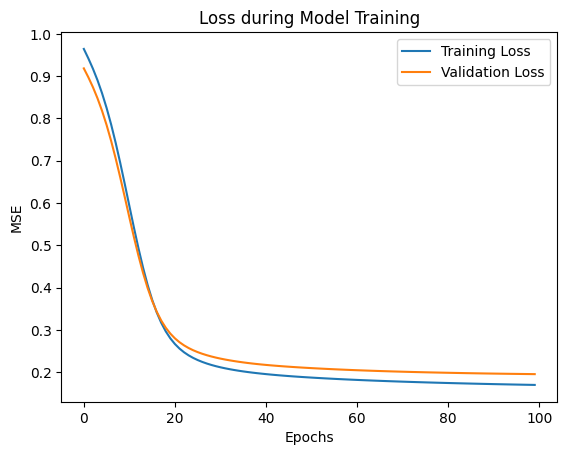

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0269 - mae: 0.8072 - val_loss: 0.9667 - val_mae: 0.7845
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9827 - mae: 0.7895 - val_loss: 0.9278 - val_mae: 0.7679
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9427 - mae: 0.7733 - val_loss: 0.8915 - val_mae: 0.7524
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9036 - mae: 0.7570 - val_loss: 0.8552 - val_mae: 0.7368
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8636 - mae: 0.7400 - val_loss: 0.8174 - val_mae: 0.7205
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8217 - mae: 0.7218 - val_loss: 0.7775 - val_mae: 0.7029
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7773 - mae: 0.7020 - val_loss: 0.7351 - val_mae: 0.6841
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7303 - mae: 0.6802 - val_loss: 0.6903 - val_mae: 0.6637
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.681

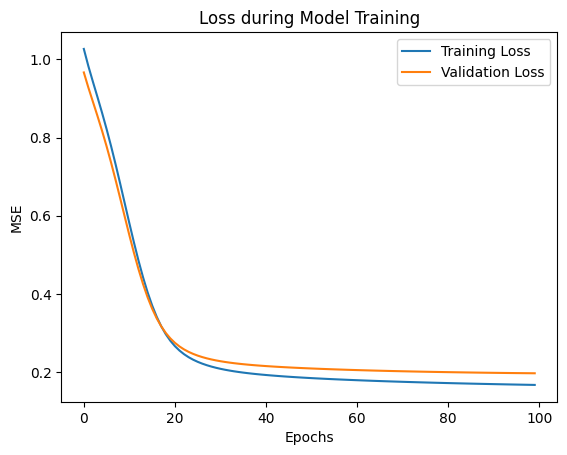

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0595 - mae: 0.8230 - val_loss: 0.9780 - val_mae: 0.7919
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9580 - mae: 0.7832 - val_loss: 0.8952 - val_mae: 0.7571
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8770 - mae: 0.7498 - val_loss: 0.8251 - val_mae: 0.7268
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8046 - mae: 0.7184 - val_loss: 0.7607 - val_mae: 0.6982
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7365 - mae: 0.6873 - val_loss: 0.6994 - val_mae: 0.6701
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6712 - mae: 0.6559 - val_loss: 0.6406 - val_mae: 0.6422
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6088 - mae: 0.6241 - val_loss: 0.5846 - val_mae: 0.6142
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5500 - mae: 0.5924 - val_loss: 0.5321 - val_mae: 0.5864
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.495

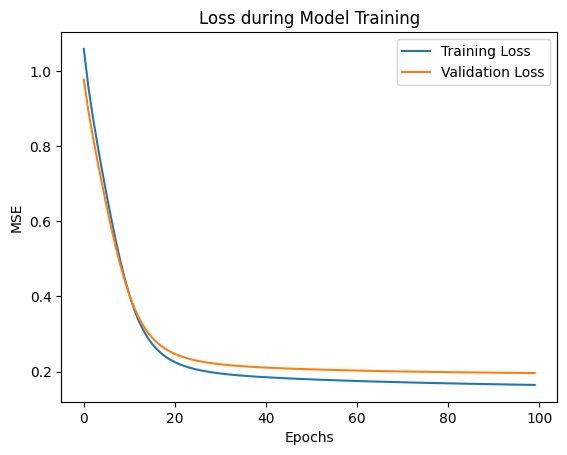

In [23]:
histories = {}
n_neuron = [16,32,64,128]




for no_of_neuron in n_neuron:
# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
    
    model = Sequential([
    Input(shape=(35,))])

    model.add(Dense(no_of_neuron, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))) # Hidden layer with 5 neurons

    model.add(Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)))
    

    
    opt = SGD(learning_rate=0.001, momentum=0.0)

    model.compile(
        optimizer=opt,
        loss='mse',
        metrics=['mae']
)

    # Train the model using GD with train dataset and validate the model using validation dataset during training
    start_time = time.time()

    history_model = model.fit(
        X_train_scaled,
        y_train_scaled,
        epochs=100,
        batch_size=32, # batch_size > training_dataset_size --> use GD
        validation_data=(X_val_scaled, y_val_scaled),
        verbose=1
    )

    end_time = time.time()
    training_time = end_time - start_time

 


    
    histories[no_of_neuron] = history_model

    # make Predictions using the Model
    y_true = y_test
    y_pred = np.argmax(model.predict(X_test_scaled), axis=1) # convert probabilities to class labels

    y_prob = model.predict(X_test_scaled)
    
    print('-----------------------------------------------------------------------------------------------------------------------')
    print('The results with %f no. of neuron', no_of_neuron)
    print('-----------------------------------------------------------------------------------------------------------------------')

   
   
   # Plot the training and validation accuracy and loss
    plt.plot(history_model.history["loss"], label="Training Loss")
    plt.plot(history_model.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.title("Loss during Model Training")
    plt.legend()
    plt.show()

  










So, we can see that with no of neuron being 128 we have the least mse and mae. So we will choose the model with one layer and 128 neurons. In the next step, we will use this best architecture so far to evaluate the effect of different activation 
functions. I will test the following activation fuctions: ReLU, tanh, and sigmoid

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0595 - mae: 0.8230 - val_loss: 0.9780 - val_mae: 0.7919
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9580 - mae: 0.7832 - val_loss: 0.8952 - val_mae: 0.7571
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8770 - mae: 0.7498 - val_loss: 0.8251 - val_mae: 0.7268
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8046 - mae: 0.7184 - val_loss: 0.7607 - val_mae: 0.6982
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7365 - mae: 0.6873 - val_loss: 0.6994 - val_mae: 0.6701
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6712 - mae: 0.6559 - val_loss: 0.6406 - val_mae: 0.6422
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6088 - mae: 0.6241 - val_loss: 0.5846 - val_mae: 0.6142
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5500 - mae: 0.5924 - val_loss: 0.5321 - val_mae: 0.5864
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.495

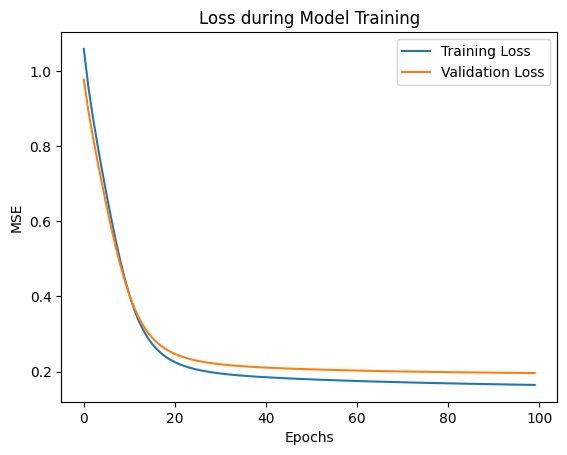

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0972 - mae: 0.8383 - val_loss: 0.9341 - val_mae: 0.7836
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8316 - mae: 0.7308 - val_loss: 0.7344 - val_mae: 0.6944
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6536 - mae: 0.6476 - val_loss: 0.5921 - val_mae: 0.6232
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5238 - mae: 0.5792 - val_loss: 0.4863 - val_mae: 0.5638
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4279 - mae: 0.5223 - val_loss: 0.4080 - val_mae: 0.5156
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3583 - mae: 0.4766 - val_loss: 0.3512 - val_mae: 0.4773
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3089 - mae: 0.4413 - val_loss: 0.3107 - val_mae: 0.4466
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2742 - mae: 0.4150 - val_loss: 0.2820 - val_mae: 0.4243
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.250

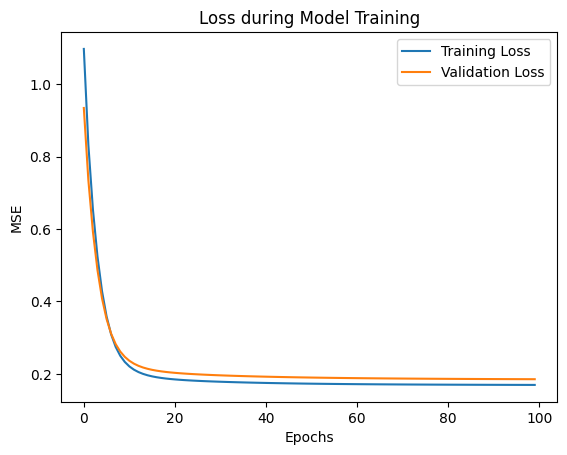

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0235 - mae: 0.8072 - val_loss: 0.9719 - val_mae: 0.7847
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0012 - mae: 0.7986 - val_loss: 0.9529 - val_mae: 0.7771
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9806 - mae: 0.7902 - val_loss: 0.9345 - val_mae: 0.7696
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9604 - mae: 0.7820 - val_loss: 0.9164 - val_mae: 0.7623
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9404 - mae: 0.7737 - val_loss: 0.8983 - val_mae: 0.7549
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9205 - mae: 0.7655 - val_loss: 0.8803 - val_mae: 0.7474
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9004 - mae: 0.7570 - val_loss: 0.8620 - val_mae: 0.7397
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8801 - mae: 0.7484 - val_loss: 0.8434 - val_mae: 0.7319
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.859

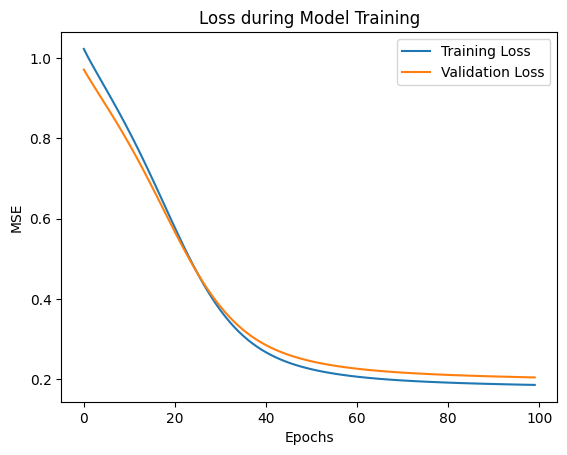

In [24]:
histories = {}
activation_function = ['relu','tanh','sigmoid']




for activation in activation_function:
# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
    
    model = Sequential([
    Input(shape=(35,))])

    model.add(Dense(128, activation=activation, kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))) # Hidden layer with 5 neurons

    model.add(Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)))
    

    
    opt = SGD(learning_rate=0.001, momentum=0.0)

    model.compile(
        optimizer=opt,
        loss='mse',
        metrics=['mae']
)

    # Train the model using GD with train dataset and validate the model using validation dataset during training
    start_time = time.time()

    history_model = model.fit(
        X_train_scaled,
        y_train_scaled,
        epochs=100,
        batch_size=32, # batch_size > training_dataset_size --> use GD
        validation_data=(X_val_scaled, y_val_scaled),
        verbose=1
    )

    end_time = time.time()
    training_time = end_time - start_time

 


    
    histories[activation] = history_model

    # make Predictions using the Model
    y_true = y_test
    y_pred = np.argmax(model.predict(X_test_scaled), axis=1) # convert probabilities to class labels

    y_prob = model.predict(X_test_scaled)
    
    print('-----------------------------------------------------------------------------------------------------------------------')
    print('The results with %f activation function', activation)
    print('-----------------------------------------------------------------------------------------------------------------------')

   
   
   # Plot the training and validation accuracy and loss
    plt.plot(history_model.history["loss"], label="Training Loss")
    plt.plot(history_model.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.title("Loss during Model Training")
    plt.legend()
    plt.show()

  










So we can see that the acivation of tanh gives us the lowest mae amd loss so we will use tanh as the activation. So our best model so far has one hidden layer, 128 neurons and activation of tanh. 

In [25]:
### Gradient Descent
# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with five neurons using ReLU activation function, and output layer which uses linear activation function to calculate output
gd_model = Sequential([
    Input(shape=(35,)),
    Dense(128, activation='tanh', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), # Hidden layer with 5 neurons
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = SGD(learning_rate=0.001, momentum=0.0)

gd_model.compile(
    optimizer=opt,
    loss="mse",
    metrics=["mae"]
)

start_time = time.time()

# Train the model using GD with train dataset and validate the model using validation dataset during training
history_gd = gd_model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
gd_training_time = end_time - start_time

print(f"Training time: {gd_training_time:.2f} seconds")
print(f"Training time: {gd_training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0972 - mae: 0.8383 - val_loss: 0.9341 - val_mae: 0.7836
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8316 - mae: 0.7308 - val_loss: 0.7344 - val_mae: 0.6944
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6536 - mae: 0.6476 - val_loss: 0.5921 - val_mae: 0.6232
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5238 - mae: 0.5792 - val_loss: 0.4863 - val_mae: 0.5638
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4279 - mae: 0.5223 - val_loss: 0.4080 - val_mae: 0.5156
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3583 - mae: 0.4766 - val_loss: 0.3512 - val_mae: 0.4773
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3089 - mae: 0.4413 - val_loss: 0.3107 - val_mae: 0.4466
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2742 - mae: 0.4150 - val_loss: 0.2820 - val_mae: 0.4243
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.250

In the next step I will investigate the effect of different optimisation algorithms, including appropriate 
tuning of their associated hyperparameters. There are three optimisation algorithms that I will investigate. They are Adam, Adagrad, RMSprob. First we check with Adam optimiser. 

In [26]:



# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
model_adam_001 = Sequential([
    Input(shape=(35,)),
    Dense(128, activation='tanh', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), # Hidden layer with 5 neurons
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.01)

model_adam_001.compile(
    optimizer=opt,
    loss="mse",
    metrics=['mae']
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam_001 = model_adam_001.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2473 - mae: 0.3908 - val_loss: 0.2600 - val_mae: 0.4071
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2072 - mae: 0.3603 - val_loss: 0.2536 - val_mae: 0.4028
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2043 - mae: 0.3580 - val_loss: 0.2525 - val_mae: 0.4015
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1999 - mae: 0.3546 - val_loss: 0.2508 - val_mae: 0.3995
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1967 - mae: 0.3527 - val_loss: 0.2590 - val_mae: 0.4054
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1920 - mae: 0.3479 - val_loss: 0.2326 - val_mae: 0.3840
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1877 - mae: 0.3420 - val_loss: 0.2461 - val_mae: 0.3940
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1739 - mae: 0.3309 - val_loss: 0.2527 - val_mae: 0.3981
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.165

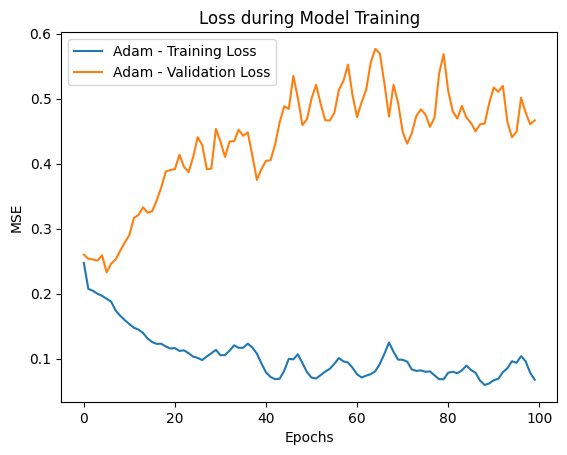

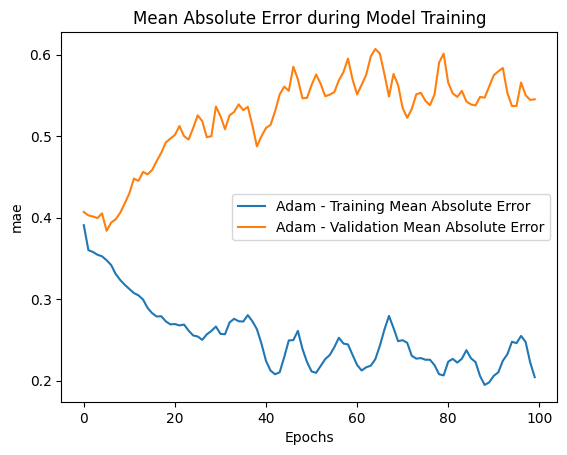

In [27]:
# Plot the training and validation accuracy and loss
plt.plot(history_adam_001.history["loss"], label="Adam - Training Loss")
plt.plot(history_adam_001.history["val_loss"], label="Adam - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

plt.plot(history_adam_001.history["mae"], label="Adam - Training Mean Absolute Error")
plt.plot(history_adam_001.history["val_mae"], label="Adam - Validation Mean Absolute Error")
plt.xlabel("Epochs")
plt.ylabel("mae")
plt.title("Mean Absolute Error during Model Training")
plt.legend()
plt.show()

So we can see that with Adam optimizer learning rate 0.01 val_mae and val_loss are quite high

In the next step, I tried adam optimizer with a smaller learning rate which is 0.001 

In [28]:



# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
model_adam_0001 = Sequential([
    Input(shape=(35,)),
    Dense(128, activation='tanh', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), # Hidden layer with 5 neurons
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.001)

model_adam_0001.compile(
    optimizer=opt,
    loss="mse",
    metrics=['mae']
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam_0001 = model_adam_0001.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3969 - mae: 0.4826 - val_loss: 0.2124 - val_mae: 0.3668
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1895 - mae: 0.3453 - val_loss: 0.1971 - val_mae: 0.3537
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1813 - mae: 0.3365 - val_loss: 0.1924 - val_mae: 0.3498
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1791 - mae: 0.3337 - val_loss: 0.1909 - val_mae: 0.3486
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1782 - mae: 0.3327 - val_loss: 0.1902 - val_mae: 0.3481
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1777 - mae: 0.3321 - val_loss: 0.1898 - val_mae: 0.3478
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1772 - mae: 0.3315 - val_loss: 0.1895 - val_mae: 0.3476
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1767 - mae: 0.3310 - val_loss: 0.1893 - val_mae: 0.3475
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.176

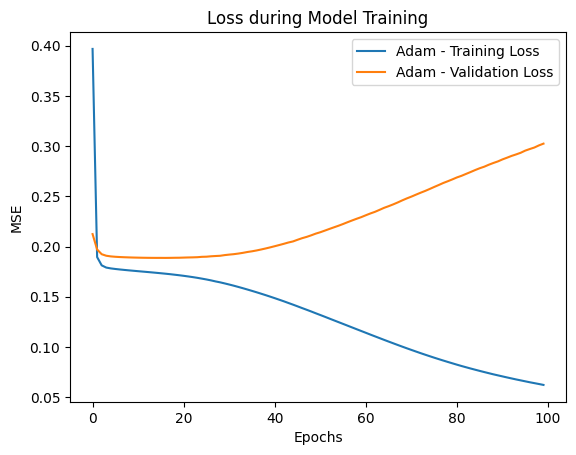

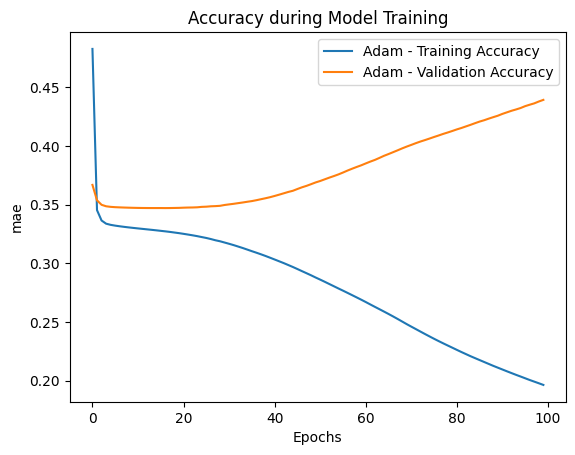

In [29]:
# Plot the training and validation accuracy and loss
plt.plot(history_adam_0001.history["loss"], label="Adam - Training Loss")
plt.plot(history_adam_0001.history["val_loss"], label="Adam - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

plt.plot(history_adam_0001.history["mae"], label="Adam - Training Accuracy")
plt.plot(history_adam_0001.history["val_mae"], label="Adam - Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("mae")
plt.title("Accuracy during Model Training")
plt.legend()
plt.show()

With adam with learning rate of 0.001, we can see that the R2_score train and validation both higher than Adam learning rate of 0.01. We will test the model with learning rate even smaller 0.0001 to chekc if we can have the score higher. 

In [30]:


# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
model_adam_00001 = Sequential([
    Input(shape=(35,)),
    Dense(128, activation='tanh', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), # Hidden layer with 5 neurons
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.0001)

model_adam_00001.compile(
    optimizer=opt,
    loss="mse",
    metrics=['mae']
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam_00001 = model_adam_00001.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0663 - mae: 0.8247 - val_loss: 0.8754 - val_mae: 0.7604
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7423 - mae: 0.6865 - val_loss: 0.6208 - val_mae: 0.6410
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5144 - mae: 0.5711 - val_loss: 0.4402 - val_mae: 0.5380
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3626 - mae: 0.4787 - val_loss: 0.3259 - val_mae: 0.4605
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2736 - mae: 0.4154 - val_loss: 0.2628 - val_mae: 0.4124
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2278 - mae: 0.3791 - val_loss: 0.2321 - val_mae: 0.3865
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2065 - mae: 0.3608 - val_loss: 0.2182 - val_mae: 0.3732
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1968 - mae: 0.3519 - val_loss: 0.2115 - val_mae: 0.3667
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.191

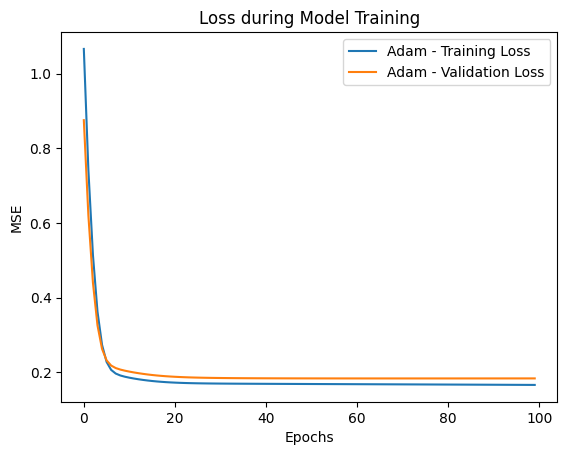

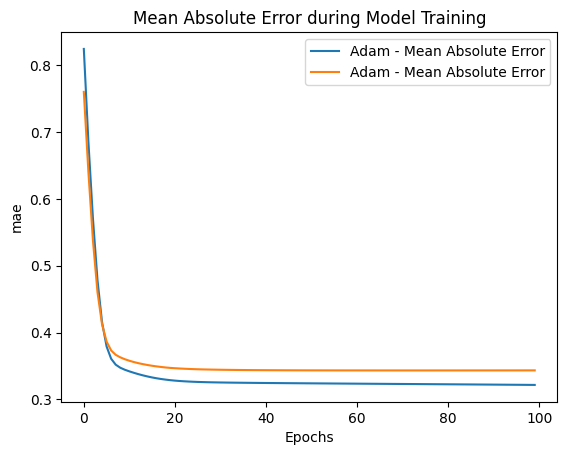

In [31]:
# Plot the training and validation accuracy and loss
plt.plot(history_adam_00001.history["loss"], label="Adam - Training Loss")
plt.plot(history_adam_00001.history["val_loss"], label="Adam - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

plt.plot(history_adam_00001.history["mae"], label="Adam - Mean Absolute Error")
plt.plot(history_adam_00001.history["val_mae"], label="Adam - Mean Absolute Error")
plt.xlabel("Epochs")
plt.ylabel("mae")
plt.title("Mean Absolute Error during Model Training")
plt.legend()
plt.show()

We can see that with the learning rate of 0.0001, the mean absolute error and loss of val_date and train_data are smaller. Therefore, I will do another ADam optimizer with learning rate of 0.00001 

In [32]:



# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
model_adam_000001 = Sequential([
    Input(shape=(35,)),
    Dense(128, activation='tanh', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), # Hidden layer with 5 neurons
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.00001)

model_adam_000001.compile(
    optimizer=opt,
    loss="mse",
    metrics=['mae']
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam_000001 = model_adam_000001.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2538 - mae: 0.8973 - val_loss: 1.2088 - val_mae: 0.8925
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2079 - mae: 0.8806 - val_loss: 1.1667 - val_mae: 0.8770
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1643 - mae: 0.8645 - val_loss: 1.1266 - val_mae: 0.8618
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1226 - mae: 0.8488 - val_loss: 1.0882 - val_mae: 0.8472
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0827 - mae: 0.8334 - val_loss: 1.0514 - val_mae: 0.8328
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0444 - mae: 0.8183 - val_loss: 1.0160 - val_mae: 0.8187
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0076 - mae: 0.8035 - val_loss: 0.9818 - val_mae: 0.8049
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9720 - mae: 0.7890 - val_loss: 0.9488 - val_mae: 0.7914
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.937

With the learning rate of 0.00001, both loss and absolute mean error for train and val data lower than with the adam of learning rate of 0.0001. So for Adam I will choose the learning rate of 0.0001. In the next step I will try the adagrad optimizer. First with the learning rate of 0.01

In [33]:
# Model
model_adagrad_001 = Sequential([
    Dense(128, activation='tanh', input_shape=(35,), kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    
    Dense(1)
])

opt = Adagrad(learning_rate=0.01)

# Compile with AdaGrad
model_adagrad_001.compile(
    optimizer=opt,
    loss='mse',
    metrics=['mae']
)

# Train
start_time = time.time()

history_adagrad_001 = model_adagrad_001.fit(
    X_train_scaled, 
    y_train_scaled, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_val_scaled, y_val_scaled)
)

end_time = time.time()
adagrad_training_time = end_time - start_time

print(f"Training time: {adagrad_training_time:.2f} seconds")
print(f"Training time: {adagrad_training_time/60:.2f} minutes")

Epoch 1/100


C:\Users\vla\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2288 - mae: 0.3755 - val_loss: 0.2013 - val_mae: 0.3577
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1813 - mae: 0.3371 - val_loss: 0.1971 - val_mae: 0.3538
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1785 - mae: 0.3339 - val_loss: 0.1954 - val_mae: 0.3521
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1771 - mae: 0.3323 - val_loss: 0.1943 - val_mae: 0.3511
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1760 - mae: 0.3312 - val_loss: 0.1934 - val_mae: 0.3504
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1752 - mae: 0.3303 - val_loss: 0.1927 - val_mae: 0.3498
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1745 - mae: 0.3296 - val_loss: 0.1921 - val_mae: 0.3493
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1739 - mae: 0.3289 - val_loss: 0.1915 - val_mae: 0.3489
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1734 - mae: 0.3

The optimizer of Agradad (learning rate 0.01) gave loss and mae just slighlty higher than Adam (with learning rate of 0.0001). I will try Agradad with learning rate 0.001

In [34]:
# Model
model_adagrad_0001 = Sequential([
    Dense(128, activation='tanh', input_shape=(35,), kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    
    Dense(1)
])

opt = Adagrad(learning_rate=0.001)

# Compile with AdaGrad
model_adagrad_0001.compile(
    optimizer=opt,
    loss='mse',
    metrics=['mae']
)

# Train
start_time = time.time()

history_adagrad_0001 = model_adagrad_0001.fit(
    X_train_scaled, 
    y_train_scaled, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_val_scaled, y_val_scaled)
)

end_time = time.time()
adagrad_training_time = end_time - start_time

print(f"Training time: {adagrad_training_time:.2f} seconds")
print(f"Training time: {adagrad_training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5973 - mae: 0.6062 - val_loss: 0.3709 - val_mae: 0.4920
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2910 - mae: 0.4277 - val_loss: 0.2658 - val_mae: 0.4147
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2288 - mae: 0.3796 - val_loss: 0.2327 - val_mae: 0.3850
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2074 - mae: 0.3619 - val_loss: 0.2193 - val_mae: 0.3723
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1981 - mae: 0.3536 - val_loss: 0.2126 - val_mae: 0.3663
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1931 - mae: 0.3491 - val_loss: 0.2086 - val_mae: 0.3629
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1898 - mae: 0.3461 - val_loss: 0.2059 - val_mae: 0.3607
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1874 - mae: 0.3437 - val_loss: 0.2037 - val_mae: 0.3590
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.185

So with the learning rate 0.001 the loss and mae of val_date is still a little higher than Adam with learning rate of 0.0001. There is not much difference, so I will stay with Adam for now. The next step I will try Adadelta

In [35]:

model_adadelta = Sequential([
    Dense(128, activation='tanh', input_shape=(35,), kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    
    Dense(1)
])


opt = Adadelta()

model_adadelta.compile(
    optimizer=opt,
    loss='mse',
    metrics=['mae']
)
start_time = time.time()

history_adadelta = model_adadelta.fit(
    X_train_scaled, 
    y_train_scaled, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_val_scaled, y_val_scaled)
)

end_time = time.time()
adadelta_training_time = end_time - start_time

print(f"Training time: {adadelta_training_time:.2f} seconds")
print(f"Training time: {adadelta_training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0944 - mae: 0.8287 - val_loss: 1.0316 - val_mae: 0.8085
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0804 - mae: 0.8233 - val_loss: 1.0192 - val_mae: 0.8038
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0667 - mae: 0.8180 - val_loss: 1.0072 - val_mae: 0.7991
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0533 - mae: 0.8128 - val_loss: 0.9953 - val_mae: 0.7945
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0401 - mae: 0.8076 - val_loss: 0.9837 - val_mae: 0.7899
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0272 - mae: 0.8025 - val_loss: 0.9722 - val_mae: 0.7854
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0144 - mae: 0.7975 - val_loss: 0.9610 - val_mae: 0.7809
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0018 - mae: 0.7925 - val_loss: 0.9498 - val_mae: 0.7764
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.989

We can see that the loss and mae of adelta optimizer is higher than with the above Adam optimizer. In the next step, I will try RMSprop optimizer with learning rate of 0.001

In [36]:
# Model
model_rmsprop_0001 = Sequential([
    Dense(128, activation='tanh', input_shape=(35,), kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    
    Dense(1)
])

# Compile with RMSProp
opt = RMSprop(learning_rate=0.001, rho=0.9)

model_rmsprop_0001.compile(
    optimizer=opt,
    loss='mse',
    metrics=['mae']
)

# Train

start_time = time.time()

history_rmsprop_0001 = model_rmsprop_0001.fit(
    X_train_scaled, 
    y_train_scaled, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_val_scaled, y_val_scaled)
)

end_time = time.time()
rmsprop_training_time = end_time - start_time

print(f"Training time: {rmsprop_training_time:.2f} seconds")
print(f"Training time: {rmsprop_training_time/60:.2f} minutes")


Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2488 - mae: 0.3887 - val_loss: 0.2064 - val_mae: 0.3627
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1900 - mae: 0.3450 - val_loss: 0.2040 - val_mae: 0.3610
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1880 - mae: 0.3430 - val_loss: 0.2031 - val_mae: 0.3603
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1865 - mae: 0.3416 - val_loss: 0.2024 - val_mae: 0.3596
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1851 - mae: 0.3402 - val_loss: 0.2018 - val_mae: 0.3590
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1838 - mae: 0.3390 - val_loss: 0.2013 - val_mae: 0.3585
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1826 - mae: 0.3379 - val_loss: 0.2008 - val_mae: 0.3580
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1814 - mae: 0.3368 - val_loss: 0.2004 - val_mae: 0.3576
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.180

So we can see that the val_loss and val_mae are higher than Adam optimizer. I try RMSprop optimizer again with the learning rate of 0.0001 

In [37]:
# Model
model_rmsprop_00001 = Sequential([
    Dense(128, activation='tanh', input_shape=(35,), kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)),
    
    Dense(1)
])

# Compile with RMSProp
opt = RMSprop(learning_rate=0.0001, rho=0.9)

model_rmsprop_00001.compile(
    optimizer=opt,
    loss='mse',
    metrics=['mae']
)

# Train

start_time = time.time()

history_rmsprop_00001 = model_rmsprop_00001.fit(
    X_train_scaled, 
    y_train_scaled, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_val_scaled, y_val_scaled)
)

end_time = time.time()
rmsprop_training_time = end_time - start_time

print(f"Training time: {rmsprop_training_time:.2f} seconds")
print(f"Training time: {rmsprop_training_time/60:.2f} minutes")


Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6246 - mae: 0.6215 - val_loss: 0.3978 - val_mae: 0.5093
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2868 - mae: 0.4234 - val_loss: 0.2493 - val_mae: 0.3993
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2093 - mae: 0.3640 - val_loss: 0.2175 - val_mae: 0.3707
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1922 - mae: 0.3484 - val_loss: 0.2068 - val_mae: 0.3620
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1846 - mae: 0.3411 - val_loss: 0.2002 - val_mae: 0.3568
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1798 - mae: 0.3363 - val_loss: 0.1959 - val_mae: 0.3535
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1768 - mae: 0.3331 - val_loss: 0.1929 - val_mae: 0.3512
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1749 - mae: 0.3310 - val_loss: 0.1910 - val_mae: 0.3496
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.173

We can illustrate the difference between optimizer in the graph below 

In [76]:
import pandas as pd

comparison_optimizer = pd.DataFrame({
    "Optimizer": ["Adam_001", "Adam_0001", "Adam_00001", "Adam_000001", "AdaGrad_001", "AdaGrad_0001", "AdaDelta", "RMSProp_001", "RMSProp_0001"],

    "Training MSE": [
        history_adam_001.history["loss"][-1],
        history_adam_0001.history["loss"][-1],
        history_adam_00001.history["loss"][-1],
        history_adam_000001.history ["loss"][-1], 
        history_adagrad_001.history["loss"][-1],
        history_adagrad_0001.history["loss"][-1],
        history_adadelta.history ["loss"][-1], 
        history_rmsprop_0001.history["loss"][-1], 
        history_rmsprop_00001.history["loss"][-1],
       
    ],

   
    "Validation MSE": [
        history_adam_001.history["val_loss"][-1],
        history_adam_0001.history["val_loss"][-1],
        history_adam_00001.history["val_loss"][-1],
        history_adam_000001.history ["val_loss"][-1], 
        history_adagrad_001.history["val_loss"][-1],
        history_adagrad_0001.history["val_loss"][-1],
        history_adadelta.history ["val_loss"][-1], 
        history_rmsprop_0001.history["val_loss"][-1], 
        history_rmsprop_00001.history["val_loss"][-1],
               
    ],

    "Training MAE": [
        history_adam_001.history["mae"][-1],
        history_adam_0001.history["mae"][-1],
        history_adam_00001.history["mae"][-1],
        history_adam_000001.history ["mae"][-1], 
        history_adagrad_001.history["mae"][-1],
        history_adagrad_0001.history["mae"][-1],
        history_adadelta.history ["mae"][-1], 
        history_rmsprop_0001.history["mae"][-1], 
        history_rmsprop_00001.history["mae"][-1],
    ],

    
    "Validation MAE": [
        history_adam_001.history["val_mae"][-1],
        history_adam_0001.history["val_mae"][-1],
        history_adam_00001.history["val_mae"][-1],
        history_adam_000001.history ["val_mae"][-1], 
        history_adagrad_001.history["val_mae"][-1],
        history_adagrad_0001.history["val_mae"][-1],
        history_adadelta.history ["val_mae"][-1], 
        history_rmsprop_0001.history["val_mae"][-1], 
        history_rmsprop_00001.history["val_mae"][-1],
    ]})
comparison_optimizer



,Optimizer,Training MSE,Validation MSE,Training MAE,Validation MAE
0,Adam_001,0.067307,0.466801,0.204371,0.545306
1,Adam_0001,0.062181,0.302511,0.196399,0.439202
2,Adam_00001,0.166304,0.183758,0.321602,0.343383
3,Adam_000001,0.179473,0.197461,0.335582,0.353857
4,AdaGrad_001,0.157663,0.186816,0.313121,0.345684
5,AdaGrad_0001,0.168439,0.184768,0.323954,0.344776
6,AdaDelta,0.343128,0.356488,0.462371,0.481000
7,RMSProp_001,0.059309,0.304039,0.189598,0.437367
8,RMSProp_0001,0.164797,0.185069,0.320004,0.344667


We save this comparison to a file:

In [77]:
comparison_optimizer.to_csv(
    "optimizer_comparison.csv",
    index=False
)

From table above, we can see that Adam_00001 give us the lowest MSE and MAE for validation data

So so far my best model is the one with Adam optimizer (learning rate = 0.0001), tanh activation, 128 neurons, 1 hidden layers it will be as following. 

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0663 - mae: 0.8247 - val_loss: 0.8754 - val_mae: 0.7604
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7423 - mae: 0.6865 - val_loss: 0.6208 - val_mae: 0.6410
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5144 - mae: 0.5711 - val_loss: 0.4402 - val_mae: 0.5380
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3626 - mae: 0.4787 - val_loss: 0.3259 - val_mae: 0.4605
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2736 - mae: 0.4154 - val_loss: 0.2628 - val_mae: 0.4124
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2278 - mae: 0.3791 - val_loss: 0.2321 - val_mae: 0.3865
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2065 - mae: 0.3608 - val_loss: 0.2182 - val_mae: 0.3732
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1968 - mae: 0.3519 - val_loss: 0.2115 - val_mae: 0.3667
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.191

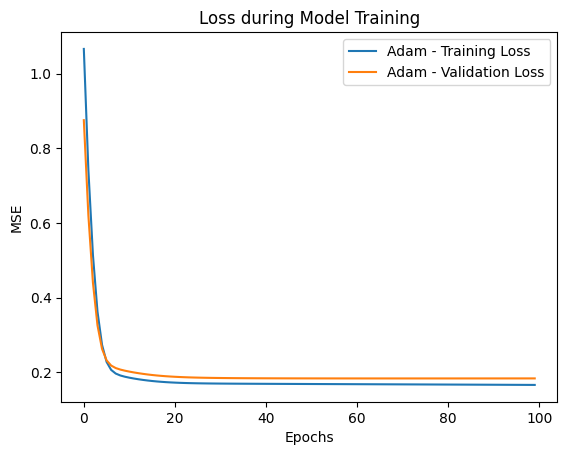

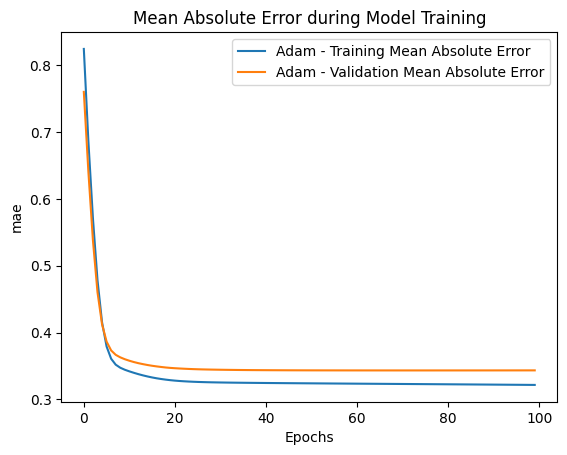

In [39]:


# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
model_adam = Sequential([
    Input(shape=(35,)),
    Dense(128, activation='tanh', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), # Hidden layer with 5 neurons
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.0001)

model_adam.compile(
    optimizer=opt,
    loss="mse",
    metrics=['mae']
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam = model_adam.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

# Plot the training and validation accuracy and loss
plt.plot(history_adam.history["loss"], label="Adam - Training Loss")
plt.plot(history_adam.history["val_loss"], label="Adam - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

plt.plot(history_adam.history["mae"], label="Adam - Training Mean Absolute Error")
plt.plot(history_adam.history["val_mae"], label="Adam - Validation Mean Absolute Error")
plt.xlabel("Epochs")
plt.ylabel("mae")
plt.title("Mean Absolute Error during Model Training")
plt.legend()
plt.show()

Evaluate suitable regularisation and generalisation techniques to reduce overfitting and improve model performance.

As shown above we can see that the model has little overfitting when at the epoch 94, validation loss and mae started slightly increase, to imrpove the performance of the model I will use early stopping 

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0663 - mae: 0.8247 - val_loss: 0.8754 - val_mae: 0.7604
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7423 - mae: 0.6865 - val_loss: 0.6208 - val_mae: 0.6410
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5144 - mae: 0.5711 - val_loss: 0.4402 - val_mae: 0.5380
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3626 - mae: 0.4787 - val_loss: 0.3259 - val_mae: 0.4605
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2736 - mae: 0.4154 - val_loss: 0.2628 - val_mae: 0.4124
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2278 - mae: 0.3791 - val_loss: 0.2321 - val_mae: 0.3865
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2065 - mae: 0.3608 - val_loss: 0.2182 - val_mae: 0.3732
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1968 - mae: 0.3519 - val_loss: 0.2115 - val_mae: 0.3667
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.191

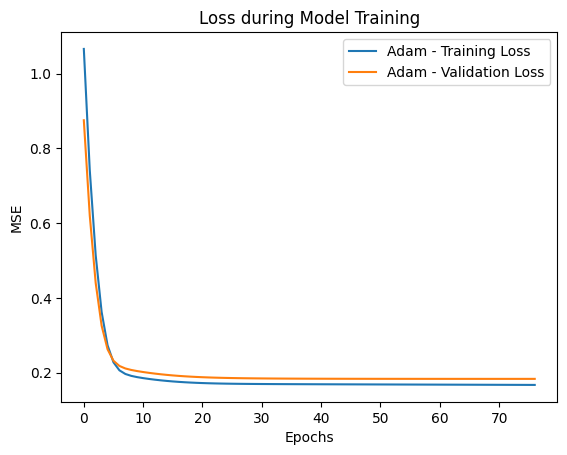

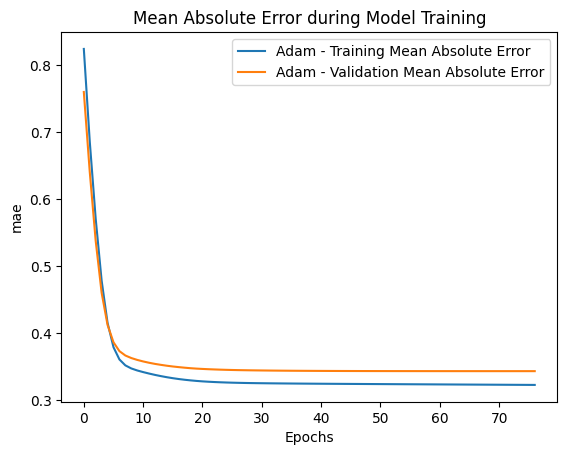

In [40]:
import keras

# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
model_adam = Sequential([
    Input(shape=(35,)),
    Dense(128, activation='tanh', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), # Hidden layer with 5 neurons
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.0001)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)



model_adam.compile(
    optimizer=opt,
    loss="mse",
    metrics=['mae']
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam = model_adam.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1, 
    callbacks=[early_stop]
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

# Plot the training and validation accuracy and loss
plt.plot(history_adam.history["loss"], label="Adam - Training Loss")
plt.plot(history_adam.history["val_loss"], label="Adam - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

plt.plot(history_adam.history["mae"], label="Adam - Training Mean Absolute Error")
plt.plot(history_adam.history["val_mae"], label="Adam - Validation Mean Absolute Error")
plt.xlabel("Epochs")
plt.ylabel("mae")
plt.title("Mean Absolute Error during Model Training")
plt.legend()
plt.show()

So we can see that the model stop at the val_mae lowest of 0.3433

Task 2.3 – Selection of the Final Model 
Using the findings in Tasks 2.2, develop your final regression model. 
Present the complete model specification including: 
• Number of hidden layers  
• Number of neurons in each layer 
• Activation functions  
• Optimiser  
• Learning rate  
• Batch size and number of epochs (or early stopping criterion, if used) 
• Regularisation techniques 
Support your architecture choices with evidence from your Task 2.2 experimental 
results, explaining why this configuration was selected over the alternatives tested.

So in the end, the model I choose is: 
• Number of hidden layers: 1 
• Number of neurons in each layer: 128
• Activation functions: tanh 
• Optimiser: Adam
• Learning rate: 0.0001 
• Batch size and number of epochs (or early stopping criterion, if used): 32 and 100
• Regularisation techniques: early stopping 
The code is as following: 

Part 3 – Model Interpretation, Critical Evaluation and 
Professional Reporting (20 Marks) 
In this final section, you will evaluate the best-performing regression model developed 
in Task 2.3, and critically discuss its performance and limitations. All conclusions 
should be supported by evidence gathered throughout the assignment.  
Task 3.1 – Model Interpretation and Critical Evaluation 
1. Model Comparison 
Summarise the performance of the baseline and final models in Table 1, using your test 
set results, reported to an appropriate number of decimal places.

Here is the baseline model: 

In [41]:
from tensorflow.keras.metrics import RootMeanSquaredError, R2Score
### Gradient Descent
# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with five neurons using ReLU activation function, and output layer which uses linear activation function to calculate output
gd_model = Sequential([
    Input(shape=(35,)),
    Dense(32, activation='relu', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), # Hidden layer with 5 neurons
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = SGD(learning_rate=0.001, momentum=0.0)

gd_model.compile(
    optimizer=opt,
    loss="mse",
    metrics=["mae",   RootMeanSquaredError(name="rmse"),"r2_score"]
)


start_time = time.time()

# Train the model using GD with train dataset and validate the model using validation dataset during training
history_gd = gd_model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
gd_training_time = end_time - start_time

print(f"Training time: {gd_training_time:.2f} seconds")
print(f"Training time: {gd_training_time/60:.2f} minutes")

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9645 - mae: 0.7825 - r2_score: 0.0355 - rmse: 0.9821 - val_loss: 0.9185 - val_mae: 0.7629 - val_r2_score: 0.0400 - val_rmse: 0.9584
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9420 - mae: 0.7733 - r2_score: 0.0580 - rmse: 0.9706 - val_loss: 0.8973 - val_mae: 0.7542 - val_r2_score: 0.0621 - val_rmse: 0.9472
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9176 - mae: 0.7632 - r2_score: 0.0824 - rmse: 0.9579 - val_loss: 0.8740 - val_mae: 0.7446 - val_r2_score: 0.0865 - val_rmse: 0.9349
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8905 - mae: 0.7518 - r2_score: 0.1095 - rmse: 0.9437 - val_loss: 0.8478 - val_mae: 0.7339 - val_r2_score: 0.1138 - val_rmse: 0.9208
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8598 - mae: 0.7386 - r2_score: 0.1402 - rmse: 0.9272 - val_loss: 0.8181 - val_mae: 0.7216 - val_r2_score: 0.1449 - val_rmse: 0.9045
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━

Evaluate the baseline model using test data

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2004 - mae: 0.3510 - r2_score: 0.8054 - rmse: 0.4476 
Test baseline Loss : 0.20037508010864258
Test baseline MAE: 0.35097336769104004
Test baseline RMSE: 0.447632759809494
Test baseline r2_score: 0.8053924441337585


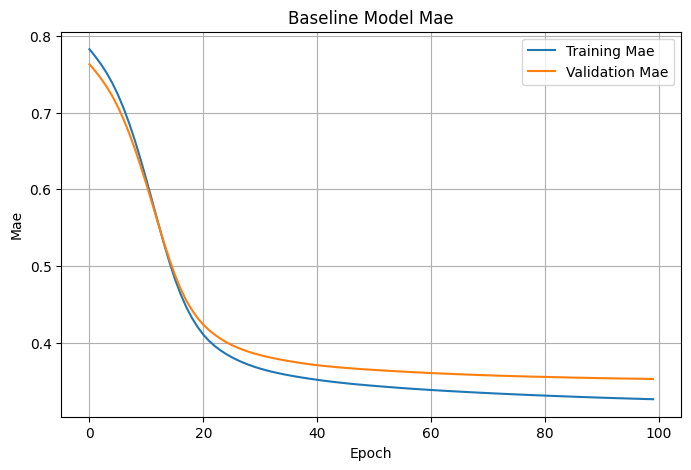

In [64]:
# Evaluate the Model
loss_baseline, mae_baseline, rmse_baseline, r2_score_baseline = gd_model.evaluate(
    X_test_scaled,
    y_test_scaled
)

print("Test baseline Loss :", loss_baseline)
print("Test baseline MAE:", mae_baseline)
print("Test baseline RMSE:", rmse_baseline)
print("Test baseline r2_score:", r2_score_baseline)

# Plot Training Mae
plt.figure(figsize=(8,5))
plt.plot(
    history_gd.history['mae'],
    label='Training Mae'
)
plt.plot(
    history_gd.history['val_mae'],
    label='Validation Mae'
)
plt.title("Baseline Model Mae")
plt.xlabel("Epoch")
plt.ylabel("Mae")
plt.legend()
plt.grid(True)
plt.show()

This is the improved model after tunninng. 

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0663 - mae: 0.8247 - r2_score: -0.0663 - rmse: 1.0326 - val_loss: 0.8754 - val_mae: 0.7604 - val_r2_score: 0.0850 - val_rmse: 0.9356
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7423 - mae: 0.6865 - r2_score: 0.2577 - rmse: 0.8616 - val_loss: 0.6208 - val_mae: 0.6410 - val_r2_score: 0.3512 - val_rmse: 0.7879
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5144 - mae: 0.5711 - r2_score: 0.4856 - rmse: 0.7172 - val_loss: 0.4402 - val_mae: 0.5380 - val_r2_score: 0.5399 - val_rmse: 0.6635
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3626 - mae: 0.4787 - r2_score: 0.6374 - rmse: 0.6022 - val_loss: 0.3259 - val_mae: 0.4605 - val_r2_score: 0.6593 - val_rmse: 0.5709
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2736 - mae: 0.4154 - r2_score: 0.7264 - rmse: 0.5231 - val_loss: 0.2628 - val_mae: 0.4124 - val_r2_score: 0.7253 - val_rmse: 0.5126
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━

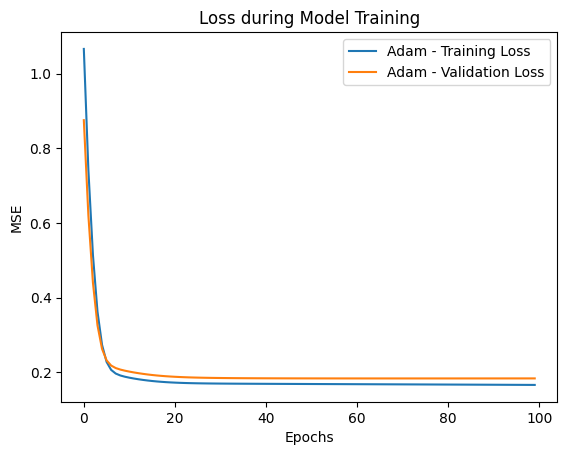

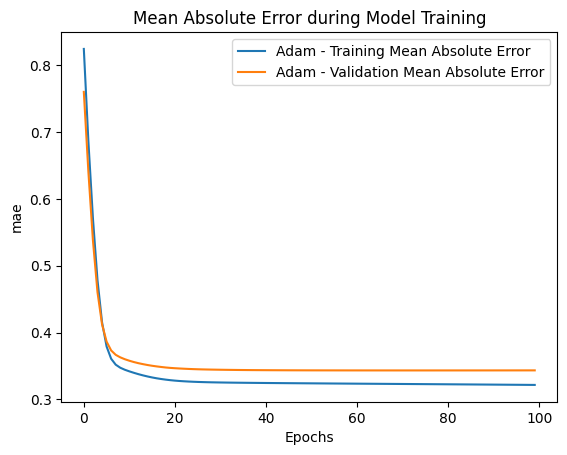

In [43]:


# Create a sequential model with input layer which takes the values of 35 input parameters as input, one hidden layer with one neuron, and output layer which uses linear activation function to calculate output
model_adam = Sequential([
    Input(shape=(35,)),
    Dense(128, activation='tanh', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42)), # Hidden layer with 5 neurons
    Dense(1, activation='linear', kernel_initializer=RandomNormal(seed=42), bias_initializer=RandomNormal(seed=42))
    ])

opt = Adam(learning_rate=0.0001)

model_adam.compile(
    optimizer=opt,
    loss="mse",
    metrics=['mae', RootMeanSquaredError(name="rmse"), "r2_score"]
)

# Train the model using GD with train dataset and validate the model using validation dataset during training
start_time = time.time()

history_adam = model_adam.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=100,
    batch_size=32, # batch_size > training_dataset_size --> use GD
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time/60:.2f} minutes")

# Plot the training and validation accuracy and loss
plt.plot(history_adam.history["loss"], label="Adam - Training Loss")
plt.plot(history_adam.history["val_loss"], label="Adam - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Loss during Model Training")
plt.legend()
plt.show()

plt.plot(history_adam.history["mae"], label="Adam - Training Mean Absolute Error")
plt.plot(history_adam.history["val_mae"], label="Adam - Validation Mean Absolute Error")
plt.xlabel("Epochs")
plt.ylabel("mae")
plt.title("Mean Absolute Error during Model Training")
plt.legend()
plt.show()

And we use this improved model for the test data 

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1892 - mae: 0.3393 - r2_score: 0.8163 - rmse: 0.4350 
Test Improved model Loss : 0.18919073045253754
Test Improved model MAE: 0.3392784297466278
Test Improved model RMSE: 0.43496060371398926
Test Improved modelr2_score: 0.8162548542022705


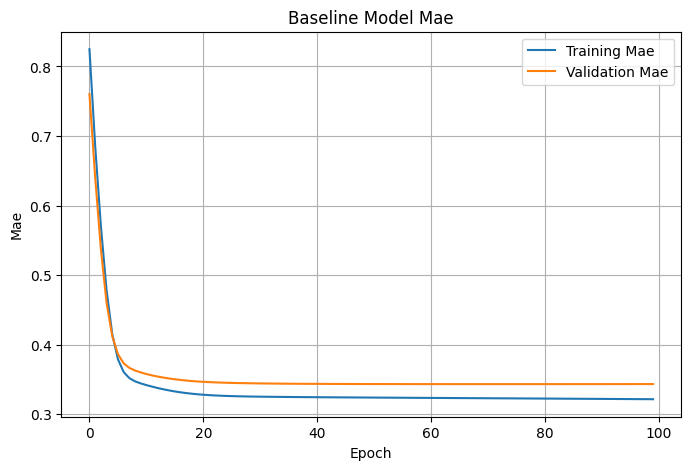

In [67]:
# Evaluate the Model
loss_improved, mae_improved, rmse_improved, r2_score_improved= model_adam.evaluate(
    X_test_scaled,
    y_test_scaled
)

print("Test Improved model Loss :", loss_improved)
print("Test Improved model MAE:", mae_improved)
print("Test Improved model RMSE:", rmse_improved)
print("Test Improved modelr2_score:", r2_score_improved)

# Plot Training Mae
plt.figure(figsize=(8,5))
plt.plot(
    history_adam.history['mae'],
    label='Training Mae'
)
plt.plot(
    history_adam.history['val_mae'],
    label='Validation Mae'
)
plt.title("Baseline Model Mae")
plt.xlabel("Epoch")
plt.ylabel("Mae")
plt.legend()
plt.grid(True)
plt.show()

In [71]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Baseline Model", "Improved model"],

    "MSE": [
        loss_baseline, loss_improved
       
    ],

   
    "MAE": [
        mae_baseline, mae_improved
               
    ],

    "RMSE": [
        rmse_baseline, rmse_improved
    ],

    
    "R2_Score": [
        r2_score_baseline, r2_score_improved
    ]})
comparison



,Model,MSE,MAE,RMSE,R2_Score
0,Baseline Model,0.200375,0.350973,0.447633,0.805392
1,Improved model,0.189191,0.339278,0.434961,0.816255


We save this result as a table 

In [72]:
comparison.to_csv(
    "model baseline_improve comparison.csv",
    index=False
)

2. Performance Discussion 
Using the results in Table 1 and any supporting plots (e.g., predicted vs. actual plot), 
discuss: 
• How accurately does the final model predict Soil Organic Carbon?  
• Has prediction accuracy improved compared with the baseline model?  
• Are prediction errors randomly distributed, or is there a pattern?  
• Are there specific observations or ranges that are consistently difficult to 
predict?

Based on the comparison between the baseline and improved model as shown above,
         Model	     MSE	        MAE	        RMSE	  R2_Score
0	Baseline Model	0.200375	0.350973	0.447633	0.805392
1	Improved model	0.189191	0.339278	0.434961	0.816255
 
 we can see that the final improved model slightly improve the prediction than the baseline mode. The model explain more than 81% the variation of the soil organic carbon

 The final model provide modest improvement from the baseline model, which shown in all the indicator, MSE slightly decrased from 0.20 to 0.18, MAE slighly decreased from 0.35 to 0.33, RMSE slightly decreased from 0.44 to 0.43 and R2_Score increased from 0.80 to 0.81




We will save the final model here 

In [73]:
model_adam.save("model_adam.keras")